#### **Importing Libraries**

In [61]:
# Importing libraries
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
import pingouin as pg

sns.set(style='whitegrid', font_scale=1.2)

#### **Loading Data**

In [57]:
# Loading the data
df = pd.read_csv('in_class_study_data.csv')

df = df.rename(columns={
    'Participant Code': 'participant_code',
    'Session Code': 'session_code',
    'Condition Code': 'condition_code',
    'Hand Dominance': 'hand_dominance',
    'Mean Completion Time (ms)': 'mean_completion_time',
    'Mean Click Error (%)': 'mean_click_error',
    'Mean Throughput (bps)': 'mean_throughput'
})

df.head()

,Filename,participant_code,session_code,condition_code,hand_dominance,Pointing Device,Device Experience,mean_completion_time,mean_click_error,mean_throughput
0,WebFitts_p1_S1_C0_Touchpad_10.0.5.156_17755423...,p1,S1,C0,Non-Dominant,Touchpad,Expert,1908.486667,0.000000,1.882376
1,WebFitts_p1_S1_C0_Touchpad_10.0.5.156_17755420...,p1,S1,C0,Dominant,Touchpad,Expert,1280.093333,0.000000,2.731876
2,WebFitts_p1_S2_C0_Touchpad_10.0.5.156_17755421...,p1,S2,C0,Dominant,Touchpad,Expert,1268.800000,6.666667,2.663982
3,WebFitts_p1_S2_C0_Touchpad_10.0.5.156_17755424...,p1,S2,C0,Non-Dominant,Touchpad,Expert,1727.126667,0.000000,1.893486
4,WebFitts_p1_S3_C0_Touchpad_10.0.5.156_17755424...,p1,S3,C0,Non-Dominant,Touchpad,Expert,1688.566667,6.666667,1.935728


#### **Visualizing Data**

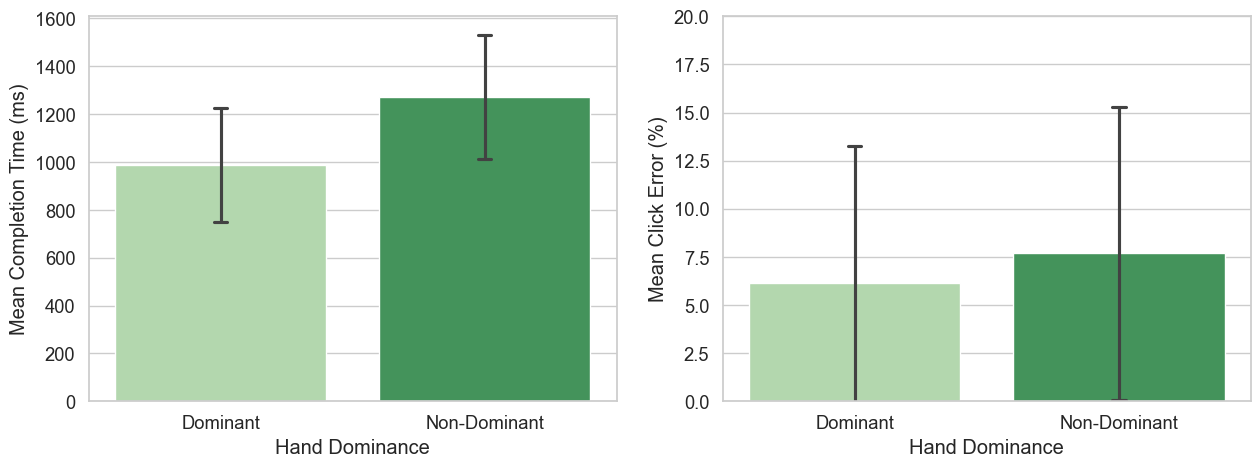

In [58]:
# Visualizing the effect of hand dominance on mean completion time and mean click error

# Creating two subfigures
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mean completion time by hand-dominance
sns.barplot(
    ax=axes[0],
    data=df, 
    x='hand_dominance', 
    y='mean_completion_time', 
    ci='sd', 
    capsize=.05, 
    order=['Dominant', 'Non-Dominant'],
    palette='Greens'
)
axes[0].set_xlabel('Hand Dominance')
axes[0].set_ylabel('Mean Completion Time (ms)')

# Mean error rate by hand-dominance
plt.gca().set_ylim(bottom=0, top=20) # Hiding negative StD values
sns.barplot(
    ax=axes[1],
    data=df, 
    x='hand_dominance', 
    y='mean_click_error', 
    ci='sd', 
    capsize=.05, 
    order=['Dominant', 'Non-Dominant'],
    palette='Greens',
)
axes[1].set_xlabel('Hand Dominance')
axes[1].set_ylabel('Mean Click Error (%)')


plt.show()


Text(0, 0.5, 'Mean Click Error (%)')

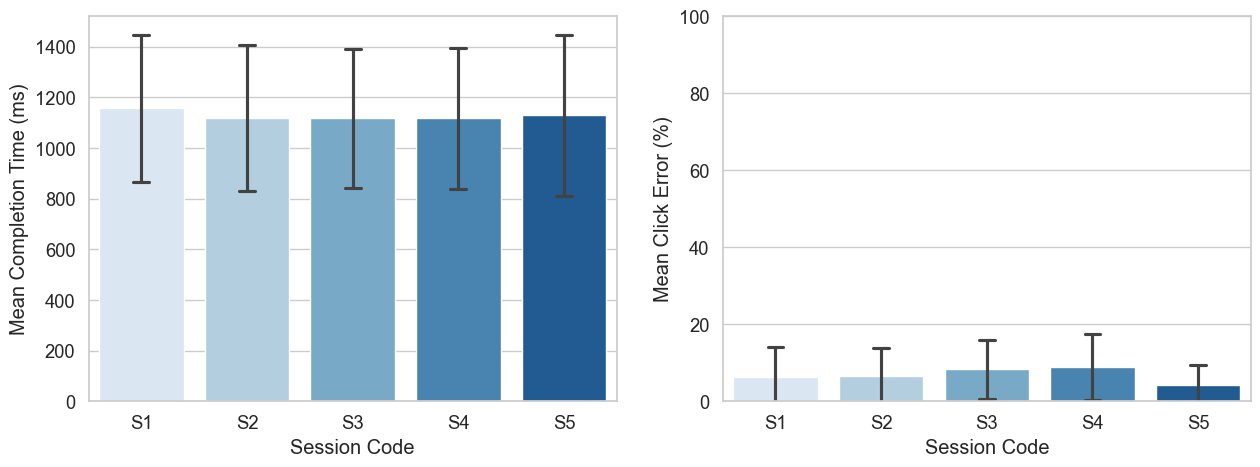

In [59]:
# Visualizing the effect of sessions on mean completion time and mean click error

# Creating two subfigures
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mean completion time by session code
sns.barplot(
    ax=axes[0],
    data=df, 
    x='session_code', 
    y='mean_completion_time',
    ci='sd', 
    capsize=.15, 
    order=['S1', 'S2', 'S3', 'S4', 'S5'],
    palette='Blues'
)
axes[0].set_xlabel('Session Code')
axes[0].set_ylabel('Mean Completion Time (ms)')

# Mean error rate by session code
plt.gca().set_ylim(bottom=0, top=100) # Hiding negative StD values
sns.barplot(
    ax=axes[1],
    data=df, 
    x='session_code', 
    y='mean_click_error', 
    ci='sd', 
    capsize=.15, 
    order=['S1', 'S2', 'S3', 'S4', 'S5'],
    palette='Blues'
)
axes[1].set_xlabel('Session Code')
axes[1].set_ylabel('Mean Click Error (%)')

#### **Two-Way ANOVA/TukeyHSD on Mean Completion Time**

,sum_sq,df,F,PR(>F)
C(hand_dominance),2.455126e+06,1.0,37.438287,1.479779e-08
C(session_code),4.939864e+04,4.0,0.188320,9.440527e-01
C(hand_dominance):C(session_code),1.660799e+04,4.0,0.063314,9.925166e-01
Residual,7.213573e+06,110.0,NaN,NaN


--- Normality Check (Shapiro-Wilk Test) ---
Statistic: 0.9634, p-value: 0.0024
Result: Reject H0. Residuals do not appear to be normally distributed.



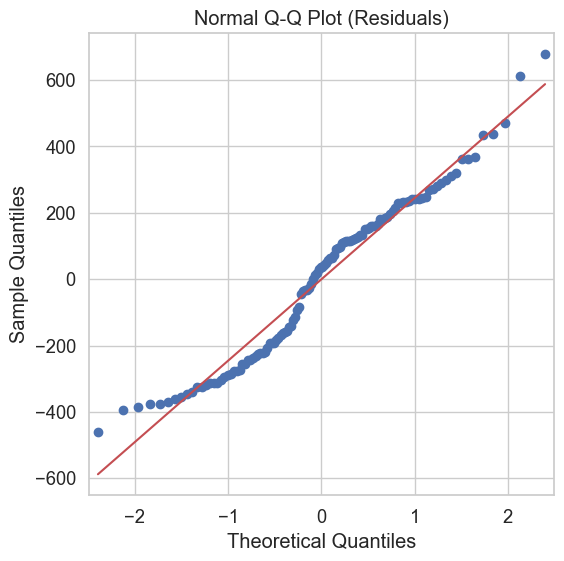

--- Homogeneity of Variance (Levene's Test for Hand Dominance) ---
Statistic: 0.0052, p-value: 0.9425
Result: Fail to reject H0. Variances are equal (Homoscedasticity met).

--- Mauchly's Test of Sphericity ---
Mauchly's W: 0.2624, p-value: 0.1880
Result: Sphericity is met (p > 0.05). Standard RM-ANOVA is valid.



In [64]:
# Two-way ANOVA for mean completion time
time_model = ols('mean_completion_time ~ C(hand_dominance) + C(session_code) + C(hand_dominance):C(session_code)', data=df).fit()
display(sm.stats.anova_lm(time_model, typ=2))

# 1. Normality Check (Shapiro-Wilk Test & Q-Q Plot)
# Assumption: The residuals should be normally distributed.
residuals = time_model.resid

# Shapiro-Wilk Test
# Assumption: Residuals are normally distributed.
shapiro_test = stats.shapiro(residuals)
print("--- Normality Check (Shapiro-Wilk Test) ---")
print(f"Statistic: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print("Result: Fail to reject H0. Residuals appear to be normally distributed.\n")
else:
    print("Result: Reject H0. Residuals do not appear to be normally distributed.\n")

# Visualizing Normality with a Q-Q Plot
plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Normal Q-Q Plot (Residuals)')
plt.show()

# 2. Homogeneity of Variance (Levene's Test)
# Assumption: The variance among groups should be equal.

levene_hand = stats.levene(
    df[df['hand_dominance'] == 'Dominant']['mean_completion_time'],
    df[df['hand_dominance'] == 'Non-Dominant']['mean_completion_time']
)

print("--- Homogeneity of Variance (Levene's Test for Hand Dominance) ---")
print(f"Statistic: {levene_hand.statistic:.4f}, p-value: {levene_hand.pvalue:.4f}")
if levene_hand.pvalue > 0.05:
    print("Result: Fail to reject H0. Variances are equal (Homoscedasticity met).\n")
else:
    print("Result: Reject H0. Variances are not equal (Heteroscedasticity detected).\n")


# 3. Mauchly's Test of Sphericity (Within-Subjects Check)
# Assumption: The variances of the differences between all 
# combinations of related groups (sessions) must be equal.

spher_test = pg.sphericity(data=df, 
                           dv='mean_completion_time', 
                           within='session_code', 
                           subject='participant_code')

print("--- Mauchly's Test of Sphericity ---")
# Returns: spher_met (bool), W-statistic, chi2, degrees of freedom, p-value
print(f"Mauchly's W: {spher_test[1]:.4f}, p-value: {spher_test[4]:.4f}")

if spher_test[0]:
    print("Result: Sphericity is met (p > 0.05). Standard RM-ANOVA is valid.\n")
else:
    print("Result: Sphericity is violated (p < 0.05). Use Greenhouse-Geisser correction.\n")

In [43]:
# TukeyHSD for mean completion time
tukey_hand = pairwise_tukeyhsd(endog=df['mean_completion_time'], groups=df['hand_dominance'], alpha=0.05)
tukey_session = pairwise_tukeyhsd(endog=df['mean_completion_time'], groups=df['session_code'], alpha=0.05)
tukey_hand_session = pairwise_tukeyhsd(endog=df['mean_completion_time'], groups=df['hand_dominance'] + df['session_code'], alpha=0.05)
print(tukey_hand)
print()
print(tukey_session)
print()
print(tukey_hand_session)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1     group2    meandiff p-adj  lower   upper  reject
-----------------------------------------------------------
Dominant Non-Dominant 284.9535   0.0 195.141 374.766   True
-----------------------------------------------------------

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
    S1     S2 -39.8775 0.9894 -272.0643 192.3093  False
    S1     S3 -40.8256 0.9884 -273.0123 191.3612  False
    S1     S4 -40.6944 0.9885 -272.8812 191.4923  False
    S1     S5 -28.5325 0.9971 -260.7193 203.6543  False
    S2     S3  -0.9481    1.0 -233.1348 231.2387  False
    S2     S4  -0.8169    1.0 -233.0037 231.3698  False
    S2     S5   11.345 0.9999 -220.8418 243.5318  False
    S3     S4   0.1311    1.0 -232.0557 232.3179  False
    S3     S5  12.2931 0.9999 -219.8937 244.4798  False
    S4     S5  12.1619 0.99

#### **Two-Way ANOVA/TukeyHSD on Mean Click Error**

In [30]:
# Two-way ANOVA for mean click error
error_model = ols('mean_click_error ~ C(hand_dominance) + C(session_code) + C(hand_dominance):C(session_code)', data=df).fit()
display(sm.stats.anova_lm(error_model, typ=2))

,sum_sq,df,F,PR(>F)
C(hand_dominance),71.830732,1.0,1.334846,0.250448
C(session_code),329.635884,4.0,1.531423,0.198037
C(hand_dominance):C(session_code),160.699701,4.0,0.746579,0.562336
Residual,5919.321419,110.0,NaN,NaN


In [53]:
# TukeyHSD for mean click error
tukey_hand = pairwise_tukeyhsd(endog=df['mean_click_error'], groups=df['hand_dominance'], alpha=0.05)
tukey_session = pairwise_tukeyhsd(endog=df['mean_click_error'], groups=df['session_code'], alpha=0.05)
tukey_hand_session = pairwise_tukeyhsd(endog=df['mean_click_error'], groups=df['hand_dominance'] + df['session_code'], alpha=0.05)
print(tukey_hand)
print()
print(tukey_session)
print()
print(tukey_hand_session)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1     group2    meandiff p-adj   lower  upper  reject
-----------------------------------------------------------
Dominant Non-Dominant   1.5634 0.2477 -1.1016 4.2284  False
-----------------------------------------------------------

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    S1     S2   0.2778 0.9999  -5.5739 6.1295  False
    S1     S3   1.9444 0.8883  -3.9073 7.7962  False
    S1     S4      2.5 0.7605  -3.3517 8.3517  False
    S1     S5  -2.2222 0.8302  -8.0739 3.6295  False
    S2     S3   1.6667 0.9332  -4.1851 7.5184  False
    S2     S4   2.2222 0.8302  -3.6295 8.0739  False
    S2     S5     -2.5 0.7605  -8.3517 3.3517  False
    S3     S4   0.5556 0.9989  -5.2962 6.4073  False
    S3     S5  -4.1667 0.2855 -10.0184 1.6851  False
    S4     S5  -4.7222 0.1738 -10.5739 1.1295  False
----------